<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 7</h3>
    <h3>Ejercicio 5_ DART</h3>
        <p>Docente: Sebastian Calcagno, Rodrigo Del Rosso, Braian Drago<p>
</div>

In [ ]:
# Se cargan las librerías
from pandas import DataFrame
from pandas import concat
import random
from scipy import stats
import numpy as np
import pandas as pd
from math import sqrt
from numpy import concatenate
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from pandas import DataFrame
from pandas import concat
import seaborn as sn
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import gc
#from darts.ad import QuantileDetector
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## **Librería DARTS**  

Darts es una biblioteca de Python para pronósticos en series temporales fáciles de usar. Contiene una variedad de modelos, desde clásicos como ARIMA hasta redes neuronales profundas. Todos los modelos de pronóstico se pueden usar de la misma manera, usando las funciones fit() y predict(), similares a scikit-learn.  

[Página Oficial](https://unit8co.github.io/darts/) [Fuente del Ejemplo](https://medium.com/unit8-machine-learning-publication/darts-time-series-made-easy-in-python-5ac2947a8878)


Es especialmente útil porque: podemos aplicar y comparar varios modelos de series temporales. facilita el proceso de preprocesamiento, modelado, ajuste y evaluacion de series de tiempo. incluye funciones de evaluación y herramientas para trabajar tanto con modelos clasicos como con tecnicas de deep learning y AutoML.

https://unit8co.github.io/darts/examples/03-FFT-examples.html

### **Exponential Smoothing**

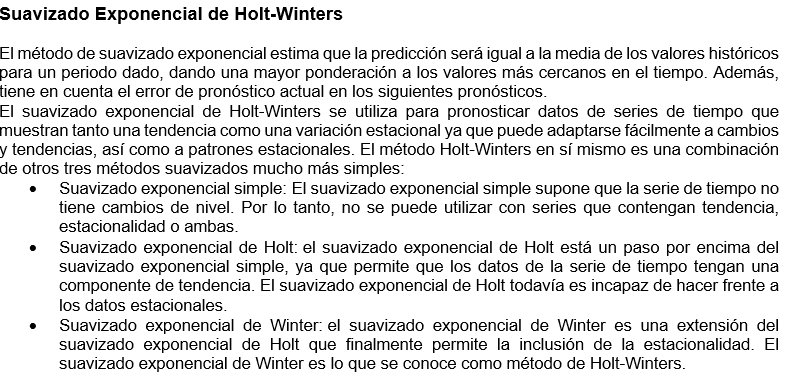

In [ ]:
! pip install darts

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.9/73.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.0/340.0 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.

In [ ]:
import darts

In [ ]:
from darts import TimeSeries
from darts.models import (NaiveSeasonal,NaiveDrift,RNNModel,Prophet,ExponentialSmoothing,ARIMA,AutoARIMA,TCNModel,TransformerModel,Theta,FFT)

In [ ]:
# Se construye el modelo SARIMA
url='https://raw.githubusercontent.com/braiandrago/AST/main/AirPassengers.csv'
custom_date_parser = lambda dates: pd.to_datetime(dates, format='%Y-%m')
df = pd.read_csv(url,parse_dates = ['Month'],date_parser = custom_date_parser)


In [ ]:
# Se redefinen las variables
df = df.rename({'Month':'ds','#Passengers':'y'}, axis='columns')
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [ ]:
train = df[:int(0.7*(len(df)))]
test = df[int(0.7*(len(df))):]

In [ ]:
# Se genera la base de entrenamiento, testeo y la base completa
train2 = TimeSeries.from_dataframe(train, 'ds', 'y')
test2 = TimeSeries.from_dataframe(test, 'ds', 'y')
df2 = TimeSeries.from_dataframe(df, 'ds', 'y')

In [ ]:
# Se inicializa, se entrena el modelo y se generan las predicciones
model = ExponentialSmoothing()
model.fit(train2)
prediction = model.predict(44)

In [ ]:
# Previsualización de las predicciones
prediction

<TimeSeries (ds: 44, component: 1, sample: 1)> Size: 352B
array([[[351.23965937]],

       [[403.3082629 ]],

       [[439.93694323]],

       [[426.79992553]],

       [[375.97302708]],

       [[329.109464  ]],

       [[295.90094029]],

       [[333.33140798]],

       [[343.40539261]],

       [[331.80934017]],

...

       [[440.25871074]],

       [[430.08786435]],

       [[434.9447488 ]],

       [[487.01335233]],

       [[523.64203266]],

       [[510.50501496]],

       [[459.67811651]],

       [[412.81455343]],

       [[379.60602972]],

       [[417.0364974 ]]])
Coordinates:
  * ds         (ds) datetime64[ns] 352B 1957-05-01 1957-06-01 ... 1960-12-01
  * component  (component) object 8B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
# Previsualización de la base de testeo
test2

<TimeSeries (ds: 44, component: 1, sample: 1)> Size: 352B
array([[[355.]],

       [[422.]],

       [[465.]],

       [[467.]],

       [[404.]],

       [[347.]],

       [[305.]],

       [[336.]],

       [[340.]],

       [[318.]],

...

       [[419.]],

       [[461.]],

       [[472.]],

       [[535.]],

       [[622.]],

       [[606.]],

       [[508.]],

       [[461.]],

       [[390.]],

       [[432.]]])
Coordinates:
  * ds         (ds) datetime64[ns] 352B 1957-05-01 1957-06-01 ... 1960-12-01
  * component  (component) object 8B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

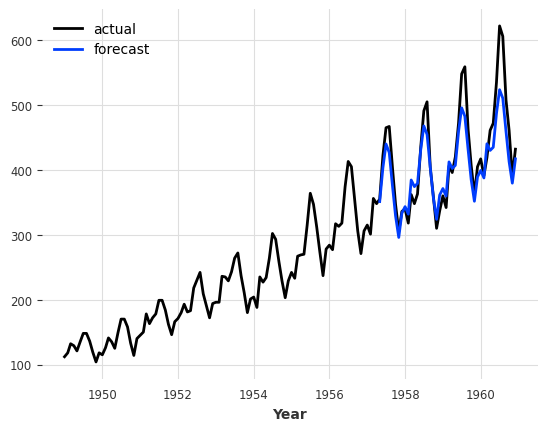

In [ ]:
# Se grafican la base completa y las predicciones
df2.plot(label='actual')
prediction.plot(label='forecast', lw=2)
plt.legend()
plt.xlabel('Year');

In [ ]:
# calculate RMSE
rmse = sqrt(mean_squared_error(test['y'], prediction.values()))
print('Test RMSE: %.3f' % rmse)
mse = mean_squared_error(test['y'], prediction.values())
print('Test MSE: %.3f' % mse)
mae = mean_absolute_error(test['y'], prediction.values())
print('Test MAE: %.3f' % mae)
r2 = r2_score(test['y'], prediction.values())
print('Test R2: %.3f' % r2)

Test RMSE: 33.629
Test MSE: 1130.898
Test MAE: 24.876
Test R2: 0.806


### **AutoARIMA**

In [ ]:
# Se inicializa, se entrena el modelo y se generan las predicciones
model_aarima = AutoARIMA(random_state = 10)
model_aarima.fit(train2)
prediction = model_aarima.predict(44)

In [ ]:
# Previsualización de las predicciones
prediction

<TimeSeries (ds: 44, component: 1, sample: 1)> Size: 352B
array([[[326.82512338]],

       [[335.89234948]],

       [[336.00132985]],

       [[338.71266135]],

       [[340.63994605]],

       [[342.78777218]],

       [[344.8651183 ]],

       [[346.96011655]],

       [[349.04822006]],

       [[351.13741391]],

...

       [[403.33961276]],

       [[405.42766722]],

       [[407.51572168]],

       [[409.60377614]],

       [[411.6918306 ]],

       [[413.77988506]],

       [[415.86793951]],

       [[417.95599397]],

       [[420.04404843]],

       [[422.13210289]]])
Coordinates:
  * ds         (ds) datetime64[ns] 352B 1957-05-01 1957-06-01 ... 1960-12-01
  * component  (component) object 8B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

Text(0.5, 0, 'Year')

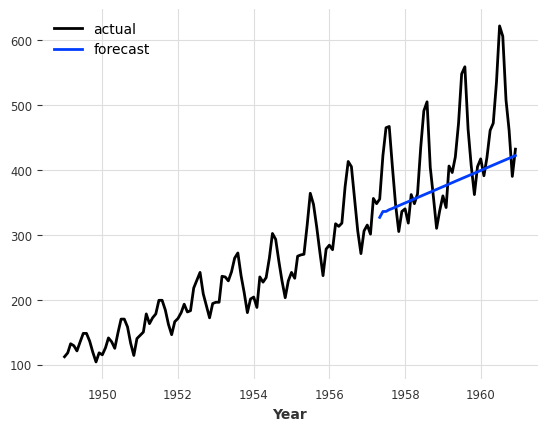

In [ ]:
# Se grafican la base completa y las predicciones
df2.plot(label='actual')
prediction.plot(label='forecast', lw=2)
plt.legend()
plt.xlabel('Year')

In [ ]:
# Cálculo de las medidas de precisión
rmse = sqrt(mean_squared_error(test['y'], prediction.values()))
print('Test RMSE: %.3f' % rmse)
mse = mean_squared_error(test['y'], prediction.values())
print('Test MSE: %.3f' % mse)
mae = mean_absolute_error(test['y'], prediction.values())
print('Test MAE: %.3f' % mae)
r2 = r2_score(test['y'], prediction.values())
print('Test R2: %.3f' % r2)

Test RMSE: 80.674
Test MSE: 6508.319
Test MAE: 58.737
Test R2: -0.114


### **RNN (LSTM)**

In [ ]:
from darts.models import RNNModel
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# Se normaliza la base
from darts.dataprocessing.transformers import Scaler
transformer = Scaler()
train_transformed = transformer.fit_transform(train2)
test_transformed = transformer.transform(test2)
series_transformed = transformer.transform(df2)

In [ ]:
model_RNN = RNNModel(
    model='LSTM',
    input_chunk_length=24,
    hidden_dim=32,
    n_rnn_layers=3,
    dropout=0.1,
    batch_size=32,
    n_epochs=100,
    optimizer_kwargs={'lr': 1e-2},
    pl_trainer_kwargs={"accelerator": "cpu"}
)

In [ ]:
model_RNN.fit(train_transformed.astype(np.float32))

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: True, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 21.4 K | train
6 | V               | Linear           | 33     | train
-------------------------------------------------------------
21.4 K    Trainable params
0         Non-trainable params
21.4 K    Total params
0.086     Total estimated model params size (MB)
7         M

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


RNNModel(model=LSTM, hidden_dim=32, n_rnn_layers=3, dropout=0.1, training_length=24, input_chunk_length=24, batch_size=32, n_epochs=100, optimizer_kwargs={'lr': 0.01}, pl_trainer_kwargs={'accelerator': 'cpu'})

In [ ]:
prediction = model_RNN.predict(n=44)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: True, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

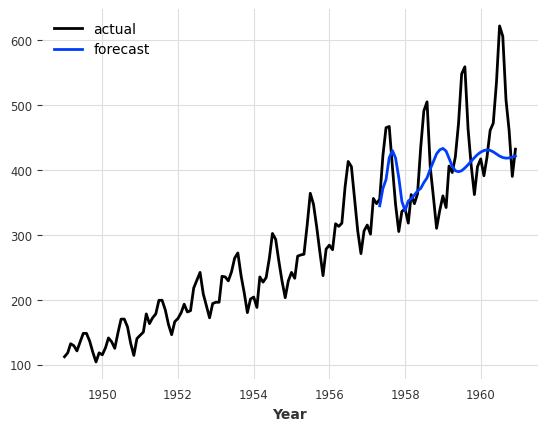

In [ ]:
# Se grafican la base completa y las predicciones
transformer.inverse_transform(series_transformed).plot(label='actual')
transformer.inverse_transform(prediction).plot(label='forecast', lw=2)
plt.legend()
plt.xlabel('Year');

In [ ]:
# Previsualización de las predicciones
transformer.inverse_transform(prediction)

<TimeSeries (ds: 44, component: 1, sample: 1)> Size: 176B
array([[[344.696  ]],

       [[371.47662]],

       [[385.07745]],

       [[418.80176]],

       [[429.7752 ]],

       [[418.51883]],

       [[388.34027]],

       [[351.50198]],

       [[337.20856]],

       [[352.21707]],

...

       [[430.8466 ]],

       [[430.14746]],

       [[427.86914]],

       [[424.57965]],

       [[421.33984]],

       [[419.08432]],

       [[418.1547 ]],

       [[418.46213]],

       [[419.68118]],

       [[421.37344]]], dtype=float32)
Coordinates:
  * ds         (ds) datetime64[ns] 352B 1957-05-01 1957-06-01 ... 1960-12-01
  * component  (component) object 8B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

In [ ]:
# Cálculo de las medidas de precisión
rmse = sqrt(mean_squared_error(test['y'], prediction.values()))
print('Test RMSE: %.3f' % rmse)
mse = mean_squared_error(test['y'], prediction.values())
print('Test MSE: %.3f' % mse)
mae = mean_absolute_error(test['y'], prediction.values())
print('Test MAE: %.3f' % mae)
r2 = r2_score(test['y'], prediction.values())
print('Test R2: %.3f' % r2)

Test RMSE: 426.996
Test MSE: 182325.234
Test MAE: 420.101
Test R2: -30.198


### **FFT (Fast Fourier Transform)**
[Artículo sobre la Transformada de Fourier](https://medium.com/@khairulomar/deconstructing-time-series-using-fourier-transform-e52dd535a44e)

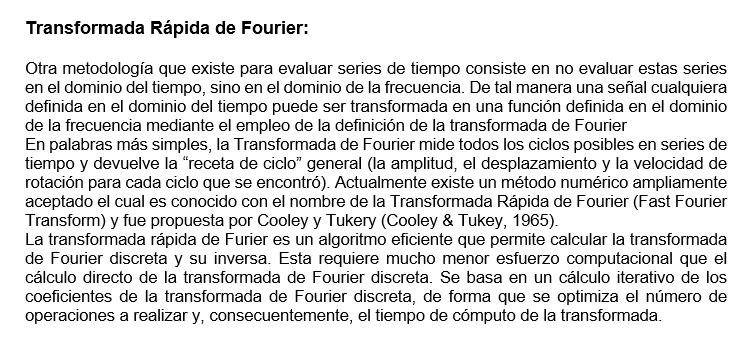

In [ ]:
# Se inicializa, se entrena el modelo y se generan las predicciones
model_FFT = FFT()
model_FFT.fit(train2)
prediction = model_FFT.predict(44)

In [ ]:
# Previsualización de las predicciones
prediction

<TimeSeries (ds: 44, component: 1, sample: 1)> Size: 352B
array([[[229.98827499]],

       [[209.84245695]],

       [[189.32751042]],

       [[170.86356052]],

       [[156.31605819]],

       [[146.44435717]],

       [[140.72204769]],

       [[137.5841489 ]],

       [[135.01488411]],

       [[131.27729662]],

...

       [[177.84484144]],

       [[166.90079717]],

       [[160.31941174]],

       [[160.44128806]],

       [[167.68321675]],

       [[180.37781883]],

       [[195.24140872]],

       [[208.34116386]],

       [[216.27720417]],

       [[217.22397943]]])
Coordinates:
  * ds         (ds) datetime64[ns] 352B 1957-05-01 1957-06-01 ... 1960-12-01
  * component  (component) object 8B 'y'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None

Text(0.5, 0, 'Year')

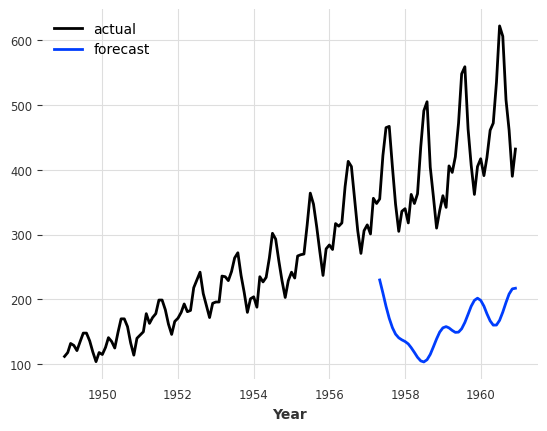

In [ ]:
# Se grafican la base completa y las predicciones
df2.plot(label='actual')
prediction.plot(label='forecast', lw=2)
plt.legend()
plt.xlabel('Year')

In [ ]:
# Cálculo de las medidas de precisión
rmse = sqrt(mean_squared_error(test['y'], prediction.values()))
print('Test RMSE: %.3f' % rmse)
mse = mean_squared_error(test['y'], prediction.values())
print('Test MSE: %.3f' % mse)
mae = mean_absolute_error(test['y'], prediction.values())
print('Test MAE: %.3f' % mae)
r2 = r2_score(test['y'], prediction.values())
print('Test R2: %.3f' % r2)

Test RMSE: 271.310
Test MSE: 73609.224
Test MAE: 259.851
Test R2: -11.596
